In [ ]:
# Cell 2: Import các thư viện
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from underthesea import word_tokenize
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch
import optuna
from datasets import Dataset
from pathlib import Path
import sys
project_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'Source' / 'ai').exists()), None)
if project_root and str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
from langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage

In [ ]:
data = pd.read_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset extractive\6000 bài đoc\bai_doc_tom_tat.xlsx")  # Thay bằng đường dẫn file của bạn
DATA = pd.DataFrame(data)
DATA

,id,title,content,Summarizex,output_len,category,topic,source,grade,publisher,summarize_short,summarize_medium,Summarize
0,1.0,Tôi là học sinh lớp 2,"Ngày khai trường đã đến. Sáng sớm, mẹ mới gọi ...",NaN,NaN,NaN,",",NaN,Lớp 2,KẾT NỐI TRI THỨC,Tôi ríu rít: “Con muốn đến sớm nhất lớp.” Tôi ...,Tôi ríu rít: “Con muốn đến sớm nhất lớp.” Tôi ...,Tôi ríu rít: “Con muốn đến sớm nhất lớp.” Tôi ...
1,2.0,Ngày hôm qua đâu rồi?,Em cầm tờ lịch cũ:\n– Ngày hôm qua đâu rồi?\nR...,NaN,NaN,NaN,NaN,NaN,Lớp 2,KẾT NỐI TRI THỨC,– Ngày hôm qua ở lại Trong vở hồng của con Con...,Em cầm tờ lịch cũ: – Ngày hôm qua đâu rồi? – N...,Em cầm tờ lịch cũ: – Ngày hôm qua đâu rồi? – N...
2,3.0,Niềm vui của Bi và Bống,"Khi cơn mưa vừa dứt, hai anh em Bi và Bống chợ...",NaN,NaN,NaN,NaN,NaN,Lớp 2,KẾT NỐI TRI THỨC,"Khi cơn mưa vừa dứt, hai anh em Bi và Bống chợ...","Khi cơn mưa vừa dứt, hai anh em Bi và Bống chợ...","Khi cơn mưa vừa dứt, hai anh em Bi và Bống chợ..."
3,4.0,Làm việc thật và vui,"Quanh ta, mọi vật, mọi người đều làm việc.\nCá...",NaN,NaN,NaN,NaN,NaN,Lớp 2,KẾT NỐI TRI THỨC,"Quanh ta, mọi vật, mọi người đều làm việc. Con...","Quanh ta, mọi vật, mọi người đều làm việc. Con...","Quanh ta, mọi vật, mọi người đều làm việc. Con..."
4,5.0,Em có xinh không?,Voi em thích mặc đẹp và thích được khen xinh. ...,NaN,NaN,NaN,NaN,NaN,Lớp 2,KẾT NỐI TRI THỨC,Voi em thích mặc đẹp và thích được khen xinh. ...,Voi em thích mặc đẹp và thích được khen xinh. ...,Voi em thích mặc đẹp và thích được khen xinh. ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6268,NaN,Tứ đại mỹ nhân thời cổ Trung Quốc là những ai?,Lịch sử Trung Quốc có bốn người đẹp làm khuynh...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Lịch sử Trung Quốc có bốn người đẹp làm khuynh...,Lịch sử Trung Quốc có bốn người đẹp làm khuynh...,Lịch sử Trung Quốc có bốn người đẹp làm khuynh...
6269,NaN,Đạo giáo đã nảy sinh như thế nào?,"Đạo giáo (hay Lão giáo), Phật giáo và Hồi giáo...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Đạo giáo (hay Lão giáo), Phật giáo và Hồi giáo...","Đạo giáo (hay Lão giáo), Phật giáo và Hồi giáo...","Đạo giáo (hay Lão giáo), Phật giáo và Hồi giáo..."
6270,NaN,Tại sao bệnh dịch hạch lại trở thành đại hoạ c...,"Ngày 24 tháng 3 năm 1345, người ta phát hiện t...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Ngày 24 tháng 3 năm 1345, người ta phát hiện t...","Ngày 24 tháng 3 năm 1345, người ta phát hiện t...","Ngày 24 tháng 3 năm 1345, người ta phát hiện t..."
6271,NaN,Đế quốc Ôt-tôman ra đời như thế nào?,"Giữa thế kỷ XIII, Tiểu Á rơi vào tình trạng hỗ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Giữa thế kỷ XIII, Tiểu Á rơi vào tình trạng hỗ...","Giữa thế kỷ XIII, Tiểu Á rơi vào tình trạng hỗ...","Giữa thế kỷ XIII, Tiểu Á rơi vào tình trạng hỗ..."


In [ ]:
Data_grade45 = DATA[DATA['grade'].isin(['Lớp 5', 'Lớp 4'])]
Data_grade3_random = DATA[DATA['grade'].isin(['Lớp 3'])].sample(n=round(len(DATA[DATA['grade'].isin(['Lớp 5'])])) + 1, random_state=42)
Data_grade345 = pd.concat([Data_grade3_random, Data_grade45])
Data_grade345

,id,title,content,Summarizex,output_len,category,topic,source,grade,publisher,summarize_short,summarize_medium,Summarize
391,442.0,Điều kì diệu,Bạn có thấy lạ không \nMỗi đứa mình một khác \...,NaN,NaN,NaN,NaN,NaN,Lớp 4,KẾT NỐI TRI THỨC,Bạn có thấy lạ không Mỗi đứa mình một khác Cùn...,Bạn có thấy lạ không Mỗi đứa mình một khác Cùn...,Bạn có thấy lạ không Mỗi đứa mình một khác Cùn...
392,443.0,Thi nhạc,Hôm nay là ngày thi tốt nghiệp của các học trò...,NaN,NaN,NaN,NaN,NaN,Lớp 4,KẾT NỐI TRI THỨC,Hôm nay là ngày thi tốt nghiệp của các học trò...,Hôm nay là ngày thi tốt nghiệp của các học trò...,Hôm nay là ngày thi tốt nghiệp của các học trò...
393,444.0,Anh em sinh đôi,Khánh và Long là anh em sinh đôi. Hai anh em g...,NaN,NaN,NaN,NaN,NaN,Lớp 4,KẾT NỐI TRI THỨC,Khánh và Long là anh em sinh đôi. Hai anh em m...,Khánh và Long là anh em sinh đôi. Hai anh em m...,Khánh và Long là anh em sinh đôi. Hai anh em m...
394,445.0,Công chúa và người dẫn chuyện,"Sau bữa ăn trưa, cô giáo thông báo Giét-xi đượ...",NaN,NaN,NaN,NaN,NaN,Lớp 4,KẾT NỐI TRI THỨC,"Sau bữa ăn trưa, cô giáo thông báo Giét-xi đượ...","Sau bữa ăn trưa, cô giáo thông báo Giét-xi đượ...","Sau bữa ăn trưa, cô giáo thông báo Giét-xi đượ..."
395,446.0,Thằn lằn xanh và tắc kè,"Một buổi tối nọ, thằn lằn xanh đang bò trên cà...",NaN,NaN,NaN,NaN,NaN,Lớp 4,KẾT NỐI TRI THỨC,"Trong khi đó, tắc kẻ cũng cảm thấy mình không ...","Một buổi tối nọ, thằn lằn xanh đang bò trên cà...","Một buổi tối nọ, thằn lằn xanh đang bò trên cà..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
225,250.0,Trò chuyện cùng mẹ,Thời gian vui nhất trong buổi tối của Thư và H...,NaN,NaN,NaN,NaN,NaN,Lớp 3,KẾT NỐI TRI THỨC,Thời gian vui nhất trong buổi tối của Thư và H...,Thời gian vui nhất trong buổi tối của Thư và H...,Thời gian vui nhất trong buổi tối của Thư và H...
261,293.0,Ngọn lửa Ô-lim-pích,Tục lệ tổ chức Đại hội Thể thao Ô-lim-pích đã ...,NaN,NaN,NaN,NaN,NaN,Lớp 3,KẾT NỐI TRI THỨC,Tục lệ tổ chức Đại hội Thể thao Ô-lim-pích đã ...,Tục lệ tổ chức Đại hội Thể thao Ô-lim-pích đã ...,Tục lệ tổ chức Đại hội Thể thao Ô-lim-pích đã ...
364,413.0,Sông quê,Gió chiều ru hiền hòa\nRung bờ tre xào xạc\nBầ...,NaN,NaN,NaN,NaN,NaN,Lớp 3,CÁNH DIỀU,Gió chiều ru hiền hòa Rung bờ tre xào xạc Bầy ...,Gió chiều ru hiền hòa Rung bờ tre xào xạc Bầy ...,Gió chiều ru hiền hòa Rung bờ tre xào xạc Bầy ...
384,433.0,Những bậc đá chạm mây,"Ngày xưa, dưới chân núi Hồng Lĩnh có một xóm n...",NaN,NaN,NaN,NaN,NaN,Lớp 3,CÁNH DIỀU,"Thấy lên núi phải đi đường vòng, ông bàn với m...","Ngày xưa, dưới chân núi Hồng Lĩnh có một xóm n...","Ngày xưa, dưới chân núi Hồng Lĩnh có một xóm n..."


| Model     | Level 1 | Level 2 | Level 3 | Level 4 | Level 5 | Cổ tích               | Bài học đời sống |
| --------- | ------- | ------- | ------- | ------- | ------- | --------------------- | ---------------- |
| **Lớp 1** | 50%     | 30%     | 0%      | 0%      | 0%      | 20% (đã lọc đơn giản) | 0%               |
| **Lớp 2** | 30%     | 40%     | 15%     | 0%      | 0%      | 15%                   | 0%               |
| **Lớp 3** | 0%      | 30%     | 40%     | 20%     | 0%      | 10%                   | 0%               |
| **Lớp 4** | 0%      | 0%      | 30%     | 40%     | 15%     | 10%                   | 5%               |
| **Lớp 5** | 0%      | 0%      | 20%     | 30%     | 30%     | 10%                   | 10%              |


In [ ]:
llm = ChatOllama(model="myaniu/qwen2.5-1m")  # hoặc "llama3:8b-instruct"

def extract_lesson(text, grade="1"):
    prompt = [
        SystemMessage(content=f"Bạn là giáo viên dạy môn học tiếng Việt cho học sinh lớp {grade} tại Việt Nam."),
        HumanMessage(content=f"""
        Đọc đoạn văn sau và rút ra bài học phù hợp với học sinh lớp {grade}.
        Viết ngắn gọn, dễ hiểu, trong chỉ 1 câu.

        ĐOẠN VĂN:
        {text}

        KẾT QUẢ:
        """)
    ]

    response = llm(prompt)
    return response.content.strip()

text = """Ngày khai trường đã đến. Sáng sớm, mẹ mới gọi một câu mà tôi đã vùng dậy, khác hẳn mọi ngày. Loáng một cái, tôi đã chuẩn bị xong mọi thứ. Bố ngạc nhiên nhìn tôi, còn mẹ cười tủm tỉm. Tôi ríu rít: “Con muốn đến sớm nhất lớp.” Tôi háo hức tưởng tượng ra cảnh mình đến đầu tiên, cất tiếng chào thật to những bạn đến sau. Nhưng vừa đến cổng trường, tôi đã thấy mấy bạn cùng lớp đang ríu rít nói cười ở trong sân. Thì ra, không chỉ mình tôi muốn đến sớm nhất. Tôi chào mẹ, chạy ào vào cùng các bạn. Chúng tôi tranh nhau kể về chuyện ngày hè. Ngay cạnh chúng tôi, mấy em lớp 1 đang rụt rè níu chặt tay bố mẹ, thật giống tôi năm ngoái. Trước các em, tôi cảm thấy mình lớn lắm. Tôi đã là học sinh lớp 2 rồi cơ mà. """
print(extract_lesson(text, grade="2"))


In [ ]:
!pip install google-cloud-vision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.9/527.9 kB 9.9 MB/s eta 0:00:00


In [ ]:

import os
from google.cloud import vision

# ✅ Thiết lập credentials đúng file JSON của bạn
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "/content/drive/MyDrive/credentials/projectsummarize-ee4dd5a1f9e8.json"

# 🔹 Khởi tạo client
client = vision.ImageAnnotatorClient()

# 🔹 Hàm OCR
def google_vision_ocr(image_path):
    with open(image_path, "rb") as image_file:
        content = image_file.read()
    image = vision.Image(content=content)
    response = client.document_text_detection(image=image)
    return response.full_text_annotation.text

# ✅ Test OCR với ảnh của bạn
image_path = "/content/drive/MyDrive/images/Screenshot 2025-10-04 154203.png"  # thay nếu khác
text = google_vision_ocr(image_path)

print("===== Kết quả OCR =====")
print(text)


===== Kết quả OCR =====
Bài Mở đầu
Em là học sinh
Em việt
Em nói
Em doc
Đồ dùng học tập
Đồ dùng học tập
Em làm việc nhóm
Em trải nghiêm
Em học ở nhà


In [ ]:
import os
from google.cloud import vision

# Đảm bảo Drive đã được mount và credentials đã set
# os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "/content/drive/MyDrive/credentials/projectsummarize-ee4dd5a1f9e8.json"

client = vision.ImageAnnotatorClient()

def google_vision_ocr(image_path):
    with open(image_path, "rb") as image_file:
        content = image_file.read()
    image = vision.Image(content=content)
    response = client.document_text_detection(image=image)
    return response.full_text_annotation.text

# 🔹 Thư mục chứa ảnh
image_folder = "/content/drive/MyDrive/images5/"
output_file = "/content/drive/MyDrive/export_to_text/vision_text5.txt"

# 🔹 Mở file để ghi (chế độ 'a' = append thêm nội dung mới)
with open(output_file, "a", encoding="utf-8") as f:
    for filename in os.listdir(image_folder):
        if filename.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".tiff")):
            image_path = os.path.join(image_folder, filename)
            print(f"🔍 Đang OCR ảnh: {filename}")
            text = google_vision_ocr(image_path)

            # Ghi vào file với tiêu đề ảnh
            f.write(f"\n===== ẢNH: {filename} =====\n")
            f.write(text + "\n")

print("✅ Hoàn thành OCR toàn bộ ảnh và lưu vào vision_text2.txt!")


🔍 Đang OCR ảnh: Screenshot 2025-10-12 161114.png
🔍 Đang OCR ảnh: Screenshot 2025-10-12 161129.png
🔍 Đang OCR ảnh: Screenshot 2025-10-12 161136.png
🔍 Đang OCR ảnh: Screenshot 2025-10-12 161138.png
🔍 Đang OCR ảnh: Screenshot 2025-10-12 161057.png
🔍 Đang OCR ảnh: Screenshot 2025-10-12 161149.png
🔍 Đang OCR ảnh: Screenshot 2025-10-12 161142.png
🔍 Đang OCR ảnh: Screenshot 2025-10-12 161151.png
🔍 Đang OCR ảnh: Screenshot 2025-10-12 161154.png
🔍 Đang OCR ảnh: Screenshot 2025-10-12 161157.png
🔍 Đang OCR ảnh: Screenshot 2025-10-12 161201.png
🔍 Đang OCR ảnh: Screenshot 2025-10-12 161207.png
🔍 Đang OCR ảnh: Screenshot 2025-10-12 161214.png
🔍 Đang OCR ảnh: Screenshot 2025-10-12 161218.png
🔍 Đang OCR ảnh: Screenshot 2025-10-12 161221.png
🔍 Đang OCR ảnh: Screenshot 2025-10-12 161226.png
🔍 Đang OCR ảnh: Screenshot 2025-10-12 161233.png
🔍 Đang OCR ảnh: Screenshot 2025-10-12 161239.png
🔍 Đang OCR ảnh: Screenshot 2025-10-12 161249.png
🔍 Đang OCR ảnh: Screenshot 2025-10-12 161253.png
🔍 Đang OCR ảnh: Scre

In [ ]:
!wget -q https://raw.githubusercontent.com/undertheseanlp/dictionary/master/dictionaries/tudientv/words.txt -O vietnamese_dict.txt

In [ ]:
!pip install -q google-generativeai

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# =====================
# Colab script: Sửa dấu + sửa lỗi nhẹ bằng từ điển (offline)
# =====================

# Yêu cầu: đã mount Drive trước đó

import json
import unicodedata
import re
from collections import defaultdict
from tqdm import tqdm

# ---------------------
# Cấu hình đường dẫn
# ---------------------
DICT_PATH = "/content/drive/MyDrive/vietnamese_dict.txt"   # file JSONL bạn đã có
INPUT_FILE = "/content/drive/MyDrive/export_to_text/vision_text5.txt"
OUTPUT_FILE = "/content/drive/MyDrive/export_to_text/vision_text_fixed5.txt"

# ---------------------
# Hàm tiện ích: remove accents (chuẩn hoá không dấu)
# ---------------------
def remove_accents(s: str) -> str:
    # chuẩn hoá NFD rồi loại bỏ các ký tự combining
    s = unicodedata.normalize('NFD', s)
    s = ''.join(ch for ch in s if unicodedata.category(ch) != 'Mn')
    # chuyển một số ký tự đặc biệt về chuẩn ascii
    s = s.replace('đ', 'd').replace('Đ', 'D')
    return unicodedata.normalize('NFC', s)

# ---------------------
# Hàm Levenshtein với ngưỡng dừng sớm (early stop)
# ---------------------
def levenshtein_with_max(a: str, b: str, max_dist: int):
    # returns distance if <= max_dist, else returns a value > max_dist
    # optimized: use two-row DP
    if abs(len(a) - len(b)) > max_dist:
        return max_dist + 1
    if len(a) < len(b):
        a, b = b, a
    previous = list(range(len(b) + 1))
    for i, ca in enumerate(a, start=1):
        current = [i] + [0] * len(b)
        # compute current row with pruning
        min_in_row = current[0]
        for j, cb in enumerate(b, start=1):
            insert_cost = current[j-1] + 1
            delete_cost = previous[j] + 1
            replace_cost = previous[j-1] + (0 if ca == cb else 1)
            current[j] = min(insert_cost, delete_cost, replace_cost)
            if current[j] < min_in_row:
                min_in_row = current[j]
        if min_in_row > max_dist:
            return max_dist + 1
        previous = current
    return previous[-1]

# ---------------------
# Load từ điển JSONL -> tập các từ hợp lệ + map không dấu -> list từ
# ---------------------
vietnamese_words = set()
deaccent_map = defaultdict(list)

print("⏳ Đang load từ điển từ:", DICT_PATH)
with open(DICT_PATH, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        try:
            item = json.loads(line)
            word = item.get("text", "").strip()
            if not word:
                continue
            # chuẩn hoá: chữ thường
            key = word.lower()
            # chỉ giữ nếu có chữ (có thể chứa space cho cụm từ)
            # loại bỏ những dòng có kí tự lạ ở đầu
            if any(ch.isalpha() for ch in key):
                vietnamese_words.add(key)
                deacc = remove_accents(key).lower()
                deaccent_map[deacc].append(key)
        except Exception as e:
            # bỏ qua dòng lỗi
            continue

print("✅ Đã load từ điển. Số từ (cụm từ) trong bộ từ điển:", len(vietnamese_words))
print("Ví dụ 20 từ:", list(vietnamese_words)[:20])

# ---------------------
# Tokenize đơn giản (giữ punctuation để phục hồi)
# ---------------------
token_split_re = re.compile(r"(\w+|[^\w\s])", flags=re.UNICODE)

def smart_tokenize(line: str):
    # trả về list token, giữ nguyên dấu câu là token riêng
    return token_split_re.findall(line)

def is_number_only(s: str):
    s_stripped = s.strip()
    # nếu chỉ có số hoặc chỉ chứa số+punct
    return bool(re.fullmatch(r"[\d\W]+", s_stripped)) and any(ch.isdigit() for ch in s_stripped)

# ---------------------
# Hàm sửa 1 token bằng từ điển
# ---------------------
def correct_token(token: str, max_lev=2):
    """
    token: token nguyên bản (có thể kèm hoa thường)
    trả về token đã sửa (giữ nguyên kiểu hoa)
    logic:
      1. nếu token trong dict -> giữ
      2. thử tìm trong deaccent_map (khớp không dấu)
      3. tìm từ gần nhất bằng levenshtein trong dictionary nhưng chỉ xét từ có độ dài tương đương
    """
    orig = token
    # giữ nguyên nếu token là punctuation
    if not any(ch.isalpha() for ch in token):
        return token

    # tách prefix/suffix punctuation (ví dụ: "Em," -> 'Em' và ',')
    prefix = re.match(r'^[^\w]*', token).group(0) if re.match(r'^[^\w]*', token) else ''
    suffix = re.search(r'[^\w]*$', token).group(0) if re.search(r'[^\w]*$', token) else ''
    core = token[len(prefix): len(token)-len(suffix) if suffix else None]

    if not core:
        return token

    # remember capitalization
    is_title = core.istitle()
    is_upper = core.isupper()

    core_low = core.lower()

    # 1) exact match
    if core_low in vietnamese_words:
        corrected = core_low
    else:
        # 2) match via deaccent map
        de = remove_accents(core_low)
        candidates = deaccent_map.get(de, [])
        if candidates:
            # choose candidate with minimal levenshtein to core_low (with limit)
            best = None
            bestd = max_lev + 10
            for c in candidates:
                d = levenshtein_with_max(core_low, c, max_lev)
                if d <= max_lev and d < bestd:
                    best = c
                    bestd = d
            if best:
                corrected = best
            else:
                # if none within max_lev, choose first candidate as fallback
                corrected = candidates[0]
        else:
            # 3) fallback: scan dictionary for nearby words (expensive but limited by length)
            best = None
            bestd = max_lev + 10
            L = len(core_low)
            # iterate through words of similar length only to reduce cost
            # choose lengths L-1, L, L+1
            for w in vietnamese_words:
                if abs(len(w) - L) > 1:
                    continue
                d = levenshtein_with_max(core_low, w, max_lev)
                if d <= max_lev and d < bestd:
                    best = w
                    bestd = d
                    if bestd == 0:
                        break
            if best:
                corrected = best
            else:
                # không tìm được -> giữ nguyên
                corrected = core_low

    # restore capitalization similar to original
    if is_upper:
        out = corrected.upper()
    elif is_title:
        out = corrected.capitalize()
    else:
        out = corrected

    return prefix + out + suffix

# ---------------------
# Xử lý toàn file
# ---------------------
print("⏳ Bắt đầu xử lý file:", INPUT_FILE)
with open(INPUT_FILE, "r", encoding="utf-8") as fin, \
     open(OUTPUT_FILE, "w", encoding="utf-8") as fout:
    for raw_line in tqdm(fin):
        line = raw_line.rstrip("\n")
        stripped = line.strip()

        # Giữ nguyên các dòng định dạng ảnh
        if stripped.startswith("=====") and "ẢNH" in stripped:
            fout.write(line + "\n")
            continue

        # Bỏ các dòng chỉ toàn số / ký tự rác
        if is_number_only(stripped):
            # bỏ hoàn toàn (hoặc có thể ghi newline nếu muốn giữ vị trí)
            # chúng ta ghi 1 dòng rỗng để giữ đôi chút format
            fout.write("\n")
            continue

        if stripped == "":
            fout.write("\n")
            continue

        # Tokenize và sửa từng token
        tokens = smart_tokenize(line)
        corrected_tokens = [correct_token(t) for t in tokens]
        new_line = "".join(
            # smart join: nếu token là word and next token is word, insert space
            # but tokenization keeps words and punctuation separate; we'll rebuild with spaces when needed
            corrected_tokens[i] + ("" if (i+1 < len(corrected_tokens) and re.match(r'[^\w\s]', corrected_tokens[i+1])) else " ")
            for i in range(len(corrected_tokens))
        ).rstrip()

        fout.write(new_line + "\n")

print("✅ Hoàn tất! File kết quả lưu tại:", OUTPUT_FILE)


⏳ Đang load từ điển từ: /content/drive/MyDrive/vietnamese_dict.txt
✅ Đã load từ điển. Số từ (cụm từ) trong bộ từ điển: 36531
Ví dụ 20 từ: ['săm se', 'khóa khí', 'yếu hèn', 'tranh đồ hoạ', 'mất mạng', 'giàn hoả', 'trời biển', 'cửa', 'nguyệt', 'cây cỏ', 'văn vần', 'chạm trán', 'ổ cứng', 'tính liệu', 'đẩy lùi', 'ké né', 'ngoay ngoảy', 'lá', 'thiển ý', 'bát ngát']
⏳ Bắt đầu xử lý file: /content/drive/MyDrive/export_to_text/vision_text5.txt


1236it [00:01, 1097.97it/s]

✅ Hoàn tất! File kết quả lưu tại: /content/drive/MyDrive/export_to_text/vision_text_fixed5.txt


In [ ]:
import json

dict_path = "/content/drive/MyDrive/vietnamese_dict.txt"  # ✅ Đường dẫn bạn cung cấp

vietnamese_words = set()
with open(dict_path, "r", encoding="utf-8") as f:
    for line in f:
        try:
            item = json.loads(line.strip())
            word = item.get("text", "").strip().lower()
            if word and word.replace(" ", "").isalpha():  # Cho phép cụm từ có dấu cách
                vietnamese_words.add(word)
        except:
            pass

print("✅ Tổng số từ trong từ điển:", len(vietnamese_words))
print(list(vietnamese_words)[:20])  # xem thử

# ==========================================
# 3️⃣ Hàm lọc từng dòng
# ==========================================
def clean_line(line):
    words = line.split()
    cleaned = [w for w in words if w.lower().strip(".,!?;:()\"'") in vietnamese_words]
    return " ".join(cleaned)

# ==========================================
# 4️⃣ Đọc file OCR gốc → tạo file sạch
# ==========================================
input_file = "/content/drive/MyDrive/export_to_text/vision_text_fixed5.txt"
output_file = "/content/drive/MyDrive/export_to_text/vision_text_clean5.txt"

with open(input_file, "r", encoding="utf-8") as fin, \
     open(output_file, "w", encoding="utf-8") as fout:
    for line in fin:
        cleaned = clean_line(line)
        fout.write(cleaned + "\n")

print("✅ Đã lọc xong! File mới tại:", output_file)


✅ Tổng số từ trong từ điển: 36167
['săm se', 'khóa khí', 'yếu hèn', 'tranh đồ hoạ', 'mất mạng', 'giàn hoả', 'trời biển', 'cửa', 'nguyệt', 'cây cỏ', 'văn vần', 'chạm trán', 'ổ cứng', 'tính liệu', 'đẩy lùi', 'ké né', 'ngoay ngoảy', 'lá', 'thiển ý', 'bát ngát']
✅ Đã lọc xong! File mới tại: /content/drive/MyDrive/export_to_text/vision_text_clean5.txt


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from langchain.schema import SystemMessage, HumanMessage
from langchain_ollama import ChatOllama

# Khởi tạo model
llm = ChatOllama(model="Tuanpham/t-visstar-7b")  # hoặc "llama3:8b-instruct"

def fix_text(filepath):
    # 1. Đọc nội dung file
    with open(filepath, "r", encoding="utf-8") as f:
        text = f.read()

    # 2. Tạo prompt
    prompt = [
        SystemMessage(content="Bạn là chuyên gia về xử lý ngôn ngữ tiếng Việt cấp bậc tiểu học tại Việt Nam."),
        HumanMessage(content=f"""
Đọc file text sau để bắt đầu sửa lỗi văn bản.
Mỗi đoạn văn cách nhau bởi chữ :'ẢNH:'.
Sửa lỗi chính tả, ngữ pháp, dấu câu, viết hoa, cách từ, đúng chuẩn tiếng Việt.
Tùy vào ngữ cảnh trong mỗi đoạn nếu như xuất hiện những từ rời rạc, không liên quan, hãy điều chỉnh lại từ đó bằng cách thay đổi dấu câu, nếu không thể, hãy loại bỏ từ đó.
Nếu xuất hiện những chữ cái, chữ số, ký hiệu rời rạc, không liên quan, hãy loại bỏ chúng.
Giữ nguyên ý nghĩa, không thêm bớt.

ĐOẠN VĂN:
{text}

KẾT QUẢ:
""")
    ]

    # 3. Gọi LLM
    response = llm(prompt)
    return response.content.strip()

# 4. Đường dẫn file input và output
file_input = r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset grade 1\Canh dieu\export_to_text\test.txt"
file_output = r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset grade 1\Canh dieu\export_to_text\vision_text_fix.txt"

# 5. Chạy sửa chính tả
fixed_text = fix_text(file_input)

# 6. Lưu kết quả ra file
with open(file_output, "w", encoding="utf-8") as f:
    f.write(fixed_text)

print("✅ Đã lưu kết quả sửa chính tả vào:", file_output)


✅ Đã lưu kết quả sửa chính tả vào: E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset grade 1\Canh dieu\export_to_text\vision_text_fix.txt


In [ ]:
import pandas as pd

dataframe = pd.DataFrame()
lst_col = ['title', 'content', 'summary', 'grade', 'publisher']
for col in lst_col:
    dataframe.insert(column= col, loc= len(dataframe.columns), value=np.nan)

file_path = r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset grade 1\Canh dieu\export_to_text\data.txt"

with open(file_path, "r", encoding="utf-8") as f:
    text = f.read()
chunks = [chunk.strip() for chunk in text.split("ẢNH:") if chunk.strip()]
for chunk in chunks:
    lines = chunk.splitlines()
    title = lines[0].strip() if lines else ""
    content = "\n".join(lines[1:]).strip() if len(lines) > 1 else ""
    dataframe = pd.concat([dataframe, pd.DataFrame({"title": [title], "content": [content], "summary": [np.nan], "grade": 1, "publisher": "CÁNH DIỀU"})], ignore_index=True)

dataframe.to_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset grade 1\canhdieu1.xlsx", index=False)

In [ ]:
import pandas as pd
import numpy as np

# 1. Khởi tạo DataFrame rỗng với các cột
lst_col = ['title', 'content', 'summary', 'grade', 'publisher']
dataframe = pd.DataFrame(columns=lst_col)

# 2. Đọc file text
file_path = r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset grade 1\Chan troi sang tao\export_to_text\data1.txt"
with open(file_path, "r", encoding="utf-8") as f:
    text = f.read()

# 3. Tách các đoạn theo "ẢNH:"
chunks = [chunk.strip() for chunk in text.split("ẢNH:") if chunk.strip()]

# 4. Duyệt từng đoạn, lấy title + content
for chunk in chunks:
    lines = chunk.splitlines()
    content = "\n".join(lines[0:]).strip() if len(lines) > 1 else ""

    # Append vào DataFrame
    dataframe = pd.concat(
        [dataframe, pd.DataFrame({
            "title": [np.nan],
            "content": [content],
            "summary": [np.nan],
            "grade": [1],
            "publisher": ["CÁNH DIỀU"]
        })],
        ignore_index=True
    )

dataframe.to_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset grade 1\chantroisangtao1.xlsx", index=False)

,title,content,summary,grade,publisher
0,NaN,Bé cùng mẹ bày cỗ Trung thu\nMẹ bày ra bàn hồn...,NaN,1,CÁNH DIỀU
1,NaN,"Tết Trung thu, ba dẫn bé ra phố,\nBé mải mê nh...",NaN,1,CÁNH DIỀU
2,NaN,"Vừa hết tháng Bảy, phố bán đồ chơi\nđã treo đầ...",NaN,1,CÁNH DIỀU
3,NaN,Tục lệ đón trăng vào giữa mùa thu\nđã có từ xa...,NaN,1,CÁNH DIỀU
4,NaN,Cô giáo tổ chức thi văn nghệ.\nBạn Hà thổi sáo...,NaN,1,CÁNH DIỀU
5,NaN,Cây bòn bon nhà bé trĩu quả. Mẹ\nhãi bòn bon c...,NaN,1,CÁNH DIỀU
6,NaN,Bé nắn nót ghi tên bé lên\nnhãn vở. Mẹ bảo: vở...,NaN,1,CÁNH DIỀU
7,NaN,Bố mẹ là bạn của bé.\nCác bạn học đều là bạn c...,NaN,1,CÁNH DIỀU
8,NaN,Ba mua về cái máy hút bụi.\nBà bảo từ ngày có ...,NaN,1,CÁNH DIỀU
9,NaN,Mẹ và bà nấu bữa trưa. Bé nhặt rau.\nChị gọt c...,NaN,1,CÁNH DIỀU


In [ ]:
data1 = pd.read_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset grade 1\final data\canhdieu.xlsx")
data2 = pd.read_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset grade 1\final data\chantroisangtao1.xlsx")
data3 = pd.read_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset grade 1\final data\chantroisangtao2.xlsx")
data4 = pd.read_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset grade 1\final data\ketnoitrithuc1.xlsx")
data5 = pd.read_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset grade 1\final data\ketnoitrithuc2.xlsx")
final_data = pd.concat([data1, data2, data3, data4, data5], ignore_index=True)
final_data = final_data.dropna(subset=['content']).reset_index(drop=True)
final_data = final_data.drop_duplicates(subset=['content']).reset_index(drop=True)
final_data.insert(column= 'meaning', loc= 3, value=np.nan)
final_data.reset_index(level=0, inplace=True)
final_data.to_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset grade 1\final data\data_grade1.xlsx", index=False)

In [ ]:
!pip install vncorenlp

# tải jar VnCoreNLP (nếu chưa có)
!wget -qO vncorenlp.zip "https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/VnCoreNLP-1.1.1.jar"
!wget https://github.com/vncorenlp/VnCoreNLP/releases/download/v1.1.1/VnCoreNLP-1.1.1.jar
!wget https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/models/wordsegmenter/vi-vocab
!wget https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/models/wordsegmenter/wordsegmenter.rdr


--2025-10-16 06:00:30--  https://github.com/vncorenlp/VnCoreNLP/releases/download/v1.1.1/VnCoreNLP-1.1.1.jar
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2025-10-16 06:00:30 ERROR 404: Not Found.

--2025-10-16 06:00:30--  https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/models/wordsegmenter/vi-vocab
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 526544 (514K) [application/octet-stream]
Saving to: ‘vi-vocab’

vi-vocab            100%[===================>] 514.20K  --.-KB/s    in 0.02s   

2025-10-16 06:00:31 (23.8 MB/s) - ‘vi-vocab’ saved [526544/526544]

--2025-10-16 06:00:31--  https://raw.githubusercontent.com/vncore

In [ ]:
# Cài đặt thư viện
!pip install vncorenlp transformers torch pandas openpyxl

# Tải jar chính thức
!wget -q https://github.com/vncorenlp/VnCoreNLP/releases/download/v1.1.1/VnCoreNLP-1.1.1.jar -O /content/VnCoreNLP-1.1.1.jar
!wget -q https://github.com/vncorenlp/VnCoreNLP/releases/download/v1.1.1/models.jar -O /content/models.jar


import pandas as pd
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModel
from vncorenlp import VnCoreNLP

# === Load dataset1 ===
df1 = pd.read_excel("/content/drive/MyDrive/data_ex/data_grade1.xlsx")

# === Load PhoBERT ===
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base", use_fast=False)
model = AutoModel.from_pretrained("vinai/phobert-base")

# === Load VnCoreNLP (standalone mode) ===
# === Load VnCoreNLP (standalone mode) ===
rdrsegmenter = VnCoreNLP(
    "/content/VnCoreNLP-1.1.1.jar",
    annotators="wseg,pos,ner,parse",
    max_heap_size='-Xmx2g'
)


# ---- Hàm tính embedding trung bình cho 1 câu ----
def get_sentence_embedding(sentence):
    inputs = tokenizer(sentence, return_tensors="pt", truncation=True, padding=True)
    with torch.no_grad():
        outputs = model(**inputs)
        hidden_states = outputs.last_hidden_state  # (batch, seq_len, hidden)
        sentence_embedding = hidden_states.mean(dim=1).squeeze()  # mean pooling
    return sentence_embedding.numpy()

# ---- Hàm trích xuất tóm tắt ----
def extract_summary_phobert(text, top_n=2):
    # Tách câu với VnCoreNLP
    sentences = rdrsegmenter.sent_tokenize(text)
    sentences = [s.strip() for s in sentences if len(s.strip()) > 3]

    if len(sentences) == 0:
        return ""
    if len(sentences) <= top_n:
        return " ".join(sentences)

    # Embedding cho từng câu
    embeddings = np.array([get_sentence_embedding(s) for s in sentences])
    # Embedding cho toàn văn bản
    doc_embedding = embeddings.mean(axis=0)

    # Tính độ tương đồng cosine
    sims = embeddings @ doc_embedding / (
        np.linalg.norm(embeddings, axis=1) * np.linalg.norm(doc_embedding)
    )

    # Chọn top_n câu quan trọng nhất
    top_ids = sims.argsort()[-top_n:][::-1]
    top_sentences = [sentences[i] for i in sorted(top_ids)]
    return " ".join(top_sentences)

# === Bổ sung summary còn thiếu ===
for i, row in df1.iterrows():
    if pd.isna(row["summary"]) or str(row["summary"]).strip() == "":
        try:
            df1.at[i, "summary"] = extract_summary_phobert(str(row["content"]), top_n=2)
        except Exception as e:
            print(f"Lỗi dòng {i}: {e}")

# === Lưu lại ===
out_path = "/content/drive/MyDrive/data_ex/data_grade1_filled.xlsx"
df1.to_excel(out_path, index=False)
print(f"✅ Đã tạo summary cho dataset1 (dùng PhoBERT + VnCoreNLP). Lưu tại: {out_path}")


ConnectionError: HTTPConnectionPool(host='127.0.0.1', port=53221): Max retries exceeded with url: /annotators (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x7d6669318ec0>: Failed to establish a new connection: [Errno 111] Connection refused'))

In [ ]:
# ==== Script robust để tạo summary (PhoBERT + VnCoreNLP fallback) ====
import os
import pandas as pd
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModel
import re
from tqdm import tqdm

# ----- Cấu hình đường dẫn (sửa nếu cần) -----
JAR_PATH = r"E:\Project_NguyenMinhVu_2211110063\Source\ai\VnCoreNLP-master\VnCoreNLP-1.1.1.jar"
INPUT_XLSX = r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset grade 1\final data\data_grade1.xlsx"
OUTPUT_XLSX = r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset grade 1\final data\data_grade1_filled.xlsx"

# ----- Load dataset -----
df1 = pd.read_excel(INPUT_XLSX)
print("Số dòng dataset:", len(df1))

# ----- Load PhoBERT -----
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base", use_fast=False)
model = AutoModel.from_pretrained("vinai/phobert-base")
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()

# ----- Try load vncorenlp wrapper, but be robust if methods differ -----
use_vncore = False
rdrsegmenter = None
try:
    from vncorenlp import VnCoreNLP
    if os.path.exists(JAR_PATH):
        rdrsegmenter = VnCoreNLP(JAR_PATH, annotators="wseg,pos,ner,parse", max_heap_size='-Xmx2g')
        use_vncore = True
        print("Đã load VnCoreNLP (standalone mode).")
    else:
        print("Không tìm thấy JAR VnCoreNLP tại:", JAR_PATH)
except Exception as e:
    print("Không thể import/run vncorenlp wrapper:", e)
    rdrsegmenter = None
    use_vncore = False

# ----- Hàm tách câu: cố gắng dùng VnCoreNLP nếu có, ngược lại fallback regex -----
sentence_splitter_regex = re.compile(r'(?<=[\.\?\!…])\s+(?=[A-ZÀ-Ỳ0-9a-zà-ỹ])', flags=re.UNICODE)

def split_sentences(text):
    text = str(text).strip()
    if not text:
        return []
    # 1) Nếu rdrsegmenter có sent_tokenize
    if rdrsegmenter is not None:
        # Một số wrapper có method sent_tokenize, một số không.
        if hasattr(rdrsegmenter, "sent_tokenize"):
            try:
                sents = rdrsegmenter.sent_tokenize(text)
                # đôi khi returned nested lists: flatten to strings
                flat = []
                for s in sents:
                    if isinstance(s, (list, tuple)):
                        flat.append(" ".join(s).strip())
                    else:
                        flat.append(str(s).strip())
                return [s for s in flat if s]
            except Exception:
                pass
        # 2) Nếu có method tokenize() trả về tokens => group tokens into sentences by punctuation
        if hasattr(rdrsegmenter, "tokenize"):
            try:
                toks = rdrsegmenter.tokenize(text)
                # tokenize may return list of lists (sentences)
                if isinstance(toks, list) and toks and isinstance(toks[0], list):
                    # join tokens per sentence
                    sents = [" ".join(sent) for sent in toks]
                    return [s.strip() for s in sents if s.strip()]
                # else fallback
            except Exception:
                pass
        # 3) Nếu có annotate method returning dict/json with 'sentences'
        if hasattr(rdrsegmenter, "annotate"):
            try:
                ann = rdrsegmenter.annotate(text)
                # ann may be dict with key 'sentences' where each sentence is list of tokens
                if isinstance(ann, dict) and "sentences" in ann:
                    sents = []
                    for s in ann["sentences"]:
                        if isinstance(s, dict) and "tokens" in s:
                            tokens = [t["form"] for t in s["tokens"] if "form" in t]
                            sents.append(" ".join(tokens).strip())
                        elif isinstance(s, list):
                            sents.append(" ".join(s).strip())
                    return [s for s in sents if s]
            except Exception:
                pass
    # 4) Fallback: simple regex split (less accurate)
    parts = re.split(r'(?<=[\.\?\!…])\s+', text)
    parts = [p.strip() for p in parts if len(p.strip()) > 0]
    if len(parts) > 1:
        return parts
    # final fallback: split by newlines
    lines = [ln.strip() for ln in re.split(r'[\n\r]+', text) if ln.strip()]
    return lines if lines else [text]

# ----- Hàm embedding câu (mean pooling) -----
def get_sentence_embedding(sentence):
    inputs = tokenizer(sentence, return_tensors="pt", truncation=True, padding=True, max_length=256)
    for k,v in inputs.items():
        inputs[k] = v.to(device)
    with torch.no_grad():
        outputs = model(**inputs)
        hidden_states = outputs.last_hidden_state  # (batch, seq_len, hidden)
        # mean pooling on token dimension (exclude padding via attention_mask)
        if "attention_mask" in inputs:
            mask = inputs["attention_mask"].unsqueeze(-1)  # (1, seq_len, 1)
            summed = (hidden_states * mask).sum(dim=1)
            denom = mask.sum(dim=1).clamp(min=1)
            sentence_embedding = (summed / denom).squeeze().cpu().numpy()
        else:
            sentence_embedding = hidden_states.mean(dim=1).squeeze().cpu().numpy()
    return sentence_embedding

# ----- Hàm extractive chọn top_n câu bằng cosine similarity với embedding document -----
def extract_summary_phobert(text, top_n=2):
    sentences = split_sentences(text)
    sentences = [s for s in sentences if len(s.strip()) > 3]
    if not sentences:
        return ""
    # if few sentences just return them joined
    if len(sentences) <= top_n:
        return " ".join(sentences)
    # compute embeddings
    embeddings = []
    for s in sentences:
        try:
            emb = get_sentence_embedding(s)
            embeddings.append(emb)
        except Exception as e:
            embeddings.append(np.zeros(768, dtype=float))  # fallback
    embeddings = np.vstack(embeddings)  # (n_sent, dim)
    doc_emb = embeddings.mean(axis=0)
    # cosine similarity
    norms = np.linalg.norm(embeddings, axis=1) * (np.linalg.norm(doc_emb) + 1e-9)
    sims = (embeddings @ doc_emb) / (norms + 1e-9)
    # pick top_n sentences but preserve original order
    top_idx = sims.argsort()[-top_n:][::-1]
    selected = [sentences[i] for i in sorted(top_idx)]
    return " ".join(selected)

# ----- Main processing: iterate rows, fill missing summary, save intermediate every K rows -----
SAVE_EVERY = 50
count_filled = 0
for i, row in tqdm(df1.iterrows(), total=len(df1), desc="Processing rows"):
    try:
        cur_sum = row.get("summary", None)
        if pd.isna(cur_sum) or str(cur_sum).strip() == "":
            content = str(row.get("content", "")).strip()
            if not content:
                df1.at[i, "summary"] = ""
            else:
                s = extract_summary_phobert(content, top_n=2)
                df1.at[i, "summary"] = s
                count_filled += 1
    except Exception as e:
        print(f"Lỗi dòng {i}: {e}")
    # save intermediate
    if i % SAVE_EVERY == 0 and i > 0:
        try:
            df1.to_excel(OUTPUT_XLSX, index=False)
            print(f"[Auto-save] Saved at row {i}")
        except Exception as se:
            print("Lưu tạm thất bại:", se)

# cuối cùng lưu kết quả
df1.to_excel(OUTPUT_XLSX, index=False)
print(f"Hoàn tất. Đã điền {count_filled} summaries. Kết quả lưu ở: {OUTPUT_XLSX}")


Số dòng dataset: 405


c:\Users\minhv\anaconda3\envs\pytorch-env\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Đã load VnCoreNLP (standalone mode).


Processing rows:   0%|          | 0/405 [00:00<?, ?it/s]C:\Users\minhv\AppData\Local\Temp\ipykernel_20316\243535558.py:159: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Bé Lê_ho , bà ạ . Ba bế cả Hà , cả bé Lê .' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df1.at[i, "summary"] = s
Processing rows:  13%|█▎        | 51/405 [00:11<01:33,  3.79it/s]

[Auto-save] Saved at row 50


...

[Auto-save] Saved at row 350


Processing rows:  99%|█████████▉| 401/405 [01:32<00:01,  3.57it/s]

[Auto-save] Saved at row 400


Processing rows: 100%|██████████| 405/405 [01:34<00:00,  4.31it/s]

Hoàn tất. Đã điền 405 summaries. Kết quả lưu ở: E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset grade 1\final data\data_grade1_filled.xlsx


In [ ]:
import pandas as pd
data_abs = pd.read_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset abstractive\DATASET SGK (2).xlsx")
data_abs.dropna(subset=['content'], inplace=True)
data_abs.drop(data_abs[data_abs['content'].str.strip().isin(['xx', 'xxx', 'xxxx'])].index, inplace=True)
data_abs_null = data_abs[data_abs['summary'].isnull()].reset_index(drop=True)
data_abs_null.to_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset abstractive\data_abs_null.xlsx", index=False)

In [5]:
!pip install google-generativeai

In [ ]:
import re
import pandas as pd
from tqdm import tqdm
import google.generativeai as genai
import os
from dotenv import load_dotenv
load_dotenv()

api_key = os.getenv("GEMINI_API_KEY")
# === 1. Load dữ liệu Excel ===
df = pd.read_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset abstractive\data_abs_null.xlsx")

# === 2. Chuẩn hóa cột grade: "Lớp 3" -> 3 ===
df["grade"] = df["grade"].astype(str).apply(
    lambda x: int(re.search(r"\d+", x).group()) if re.search(r"\d+", x) else 3
)

# === 3. Khởi tạo client Gemini ===
genai.configure(api_key=api_key)  # 👉 thay bằng API key thật
model = genai.GenerativeModel("models/gemini-2.5-flash")

# === 4. Hàm sinh tóm tắt ===
def generate_summary(text, grade):
    if pd.isna(text) or str(text).strip() == "":
        return ""  # bỏ qua nếu trống

    # Prompt cấp văn bản
    base_prompt = """
    Bạn là một giáo viên tiểu học.
    Nhiệm vụ của bạn là tạo bản tóm tắt ngắn gọn, dễ hiểu cho học sinh tiểu học.
    - Xác định thông điệp chính và sự kiện quan trọng.
    - Sử dụng ngôn ngữ đơn giản, gắn kết với trải nghiệm học sinh.
    - Viết trôi chảy, dễ đọc, đúng ngữ pháp.
    """

    # Prompt cấp lớp
    grade_prompts = {
        1: "Tóm tắt cho lớp 1-2: mỗi câu ≤ 10 từ, từ vựng cơ bản, 3-4 câu.",
        2: "Tóm tắt cho lớp 1-2: mỗi câu ≤ 10 từ, từ vựng cơ bản, 3-4 câu.",
        3: "Tóm tắt cho lớp 3-4: mỗi câu 10-12 từ, từ vựng mở rộng, 4-5 câu.",
        4: "Tóm tắt cho lớp 3-4: mỗi câu 10-12 từ, từ vựng mở rộng, 4-5 câu.",
        5: "Tóm tắt cho lớp 5: mỗi câu 12-15 từ, từ vựng phong phú, 5-6 câu."
    }

    grade = int(grade) if grade in grade_prompts else 3
    prompt = f"{base_prompt}\n\n{grade_prompts[grade]}\n\nĐoạn văn:\n{text}\n\nTóm tắt:"

    try:
        resp = model.generate_content(prompt)
        return resp.text.strip()
    except Exception as e:
        return f"Lỗi: {e}"

# === 5. Áp dụng tạo tóm tắt cho từng dòng ===
for i in tqdm(range(len(df))):
    if pd.isna(df.at[i, "summary"]) or str(df.at[i, "summary"]).strip() == "":
        try:
            df.at[i, "summary"] = generate_summary(df.at[i, "content"], df.at[i, "grade"])
        except Exception as e:
            print(f"⚠️ Lỗi dòng {i}: {e}")

# === 6. Lưu lại file Excel mới ===
out_path = r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset abstractive\data_abs_filled.xlsx"
df.to_excel(out_path, index=False)
print(f"✅ Đã tạo bản tóm tắt và lưu tại {out_path}")


  0%|          | 0/349 [00:00<?, ?it/s]C:\Users\minhv\AppData\Local\Temp\ipykernel_14380\1540549116.py:54: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Chào các em học sinh thân mến! Hôm nay, chúng ta cùng tìm hiểu về một lễ hội rất đặc biệt và sôi động nhé!

Hội đua ghe ngo là lễ hội lớn, rất vui.
Ghe ngo làm bằng gỗ, dài, sơn màu sặc sỡ.
Mỗi ghe chở hai mươi đến bốn mươi người chèo.
Các tay chèo cùng nhau đẩy ghe lướt nhanh.
Tiếng trống, tiếng reo hò làm náo nhiệt cả sông.' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.at[i, "summary"] = generate_summary(df.at[i, "content"], df.at[i, "grade"])
100%|██████████| 349/349 [1:22:55<00:00, 14.26s/it] 

✅ Đã tạo bản tóm tắt và lưu tại E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset abstractive\data_abs_filled.xlsx


In [5]:
import pandas as pd
import numpy as np
data_abs_clean = pd.read_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset abstractive\data_abs_filled.xlsx")

data_abs_clean['summary'] = data_abs_clean['summary'].replace(r'^Lỗi:.*', np.nan, regex=True)
data_abs_clean

,id,title,content,summary,output_len,category,topic,source,grade,publisher
0,424.0,Hội đua ghe ngo,Hội đua ghe ngo diễn ra vào dịp lễ hội Cúng Tr...,"Chào các em học sinh thân mến! Hôm nay, chúng ...",NaN,NaN,NaN,NaN,3,CÁNH DIỀU
1,425.0,Nhớ Việt Bắc,"Ta về, mình có nhớ ta\nTa về, ta nhớ những hoa...",Chào các bạn học sinh yêu quý!\n\nBài thơ này ...,NaN,NaN,NaN,NaN,3,CÁNH DIỀU
2,426.0,Chú hải quân,Vững vàng trên đảo nhỏ\nBồng súng gác biển trờ...,"Chào các bạn học sinh tiểu học! Hôm nay, cô sẽ...",NaN,NaN,NaN,NaN,3,CÁNH DIỀU
3,427.0,Chàng trai làng Phù Ủng,Phạm Ngũ Lão là một vị tướng giỏi thời nhà Trầ...,Chào các em học sinh! Hôm nay chúng ta cùng tì...,NaN,NaN,NaN,NaN,3,CÁNH DIỀU
4,428.0,Hai Bà Trưng,"Thuở xưa, nước ta bị giặc ngoại xâm đô hộ. Chú...","Chào các bạn nhỏ lớp 3, lớp 4! Hôm nay chúng t...",NaN,NaN,NaN,NaN,3,CÁNH DIỀU
...,...,...,...,...,...,...,...,...,...,...
344,828.0,Chiếc khí cầu,"Sau hai ngày đêm di chuyển trên không, các nhà...","Chào các em học sinh lớp 5! Hôm nay, chúng ta ...",NaN,NaN,NaN,NaN,5,CÁNH DIỀU
345,829.0,Bạn muốn lên Mặt Trăng?,Mặt Trăng xa hơn rất nhiều so với chúng ta tưở...,"Chào các em học sinh lớp 5! Hôm nay, chúng ta ...",NaN,NaN,NaN,NaN,5,CÁNH DIỀU
346,831.0,Ngày hội,Như trăm sông dồn biển\nBầu bạn tụ về đây\nThế...,Chào các em học sinh lớp 5 đáng yêu! Hôm nay c...,NaN,NaN,NaN,NaN,5,CÁNH DIỀU
347,833.0,Cô gái mũ nồi xanh,Đất Trung Phi chưa sạch mùi thuốc pháo\nThấp t...,Chào các em học sinh lớp 5! Các em hãy cùng tì...,NaN,NaN,NaN,NaN,5,CÁNH DIỀU


In [ ]:
# import re
# import pandas as pd
# import numpy as np

# def clean_intro(text, max_remove=2):
#     if pd.isna(text):  
#         return text
    
#     # Tách câu theo . ! ? kèm theo khoảng trắng xuống dòng
#     sentences = re.split(r'(?<=[.!?])\s+', text.strip())
    
#     # Nếu chỉ có 1 câu thì bỏ luôn
#     if len(sentences) <= max_remove:
#         return ""
    
#     # Bỏ tối đa 2 câu đầu
#     return " ".join(sentences[max_remove:]).strip()

# data_abs_clean['summary'] = data_abs_clean['summary'].apply(lambda x: clean_intro(x, max_remove=2))
# data_abs_clean

,id,title,content,summary,output_len,category,topic,source,grade,publisher
0,424.0,Hội đua ghe ngo,Hội đua ghe ngo diễn ra vào dịp lễ hội Cúng Tr...,"Hội đua ghe ngo là lễ hội lớn, rất vui. Ghe ng...",NaN,NaN,NaN,NaN,3,CÁNH DIỀU
1,425.0,Nhớ Việt Bắc,"Ta về, mình có nhớ ta\nTa về, ta nhớ những hoa...","* Ta nhớ cảnh rừng xanh, hoa đỏ tươi, con ng...",NaN,NaN,NaN,NaN,3,CÁNH DIỀU
2,426.0,Chú hải quân,Vững vàng trên đảo nhỏ\nBồng súng gác biển trờ...,Các chú bộ đội dũng cảm canh giữ biển đảo xa x...,NaN,NaN,NaN,NaN,3,CÁNH DIỀU
3,427.0,Chàng trai làng Phù Ủng,Phạm Ngũ Lão là một vị tướng giỏi thời nhà Trầ...,"Phạm Ngũ Lão là một vị tướng giỏi, rất yêu nướ...",NaN,NaN,NaN,NaN,3,CÁNH DIỀU
4,428.0,Hai Bà Trưng,"Thuở xưa, nước ta bị giặc ngoại xâm đô hộ. Chú...","Ngày xưa, nước ta bị giặc dữ đô hộ, dân lành p...",NaN,NaN,NaN,NaN,3,CÁNH DIỀU
...,...,...,...,...,...,...,...,...,...,...
344,828.0,Chiếc khí cầu,"Sau hai ngày đêm di chuyển trên không, các nhà...","Bác sĩ Phơ-gu-xơn hạ khí cầu, dân làng tưởng n...",NaN,NaN,NaN,NaN,5,CÁNH DIỀU
345,829.0,Bạn muốn lên Mặt Trăng?,Mặt Trăng xa hơn rất nhiều so với chúng ta tưở...,Mặt Trăng thật xa xôi; máy bay và tàu hỏa khôn...,NaN,NaN,NaN,NaN,5,CÁNH DIỀU
346,831.0,Ngày hội,Như trăm sông dồn biển\nBầu bạn tụ về đây\nThế...,Khu trại hè đã tập hợp rất nhiều bạn nhỏ đến t...,NaN,NaN,NaN,NaN,5,CÁNH DIỀU
347,833.0,Cô gái mũ nồi xanh,Đất Trung Phi chưa sạch mùi thuốc pháo\nThấp t...,Cô dạy các em hát dân ca Việt Nam và cùng nhau...,NaN,NaN,NaN,NaN,5,CÁNH DIỀU


In [6]:
data_abs_clean.insert(column= 'summary_clean', loc= 4, value=np.nan)
data_abs_clean

,id,title,content,summary,summary_clean,output_len,category,topic,source,grade,publisher
0,424.0,Hội đua ghe ngo,Hội đua ghe ngo diễn ra vào dịp lễ hội Cúng Tr...,"Chào các em học sinh thân mến! Hôm nay, chúng ...",NaN,NaN,NaN,NaN,NaN,3,CÁNH DIỀU
1,425.0,Nhớ Việt Bắc,"Ta về, mình có nhớ ta\nTa về, ta nhớ những hoa...",Chào các bạn học sinh yêu quý!\n\nBài thơ này ...,NaN,NaN,NaN,NaN,NaN,3,CÁNH DIỀU
2,426.0,Chú hải quân,Vững vàng trên đảo nhỏ\nBồng súng gác biển trờ...,"Chào các bạn học sinh tiểu học! Hôm nay, cô sẽ...",NaN,NaN,NaN,NaN,NaN,3,CÁNH DIỀU
3,427.0,Chàng trai làng Phù Ủng,Phạm Ngũ Lão là một vị tướng giỏi thời nhà Trầ...,Chào các em học sinh! Hôm nay chúng ta cùng tì...,NaN,NaN,NaN,NaN,NaN,3,CÁNH DIỀU
4,428.0,Hai Bà Trưng,"Thuở xưa, nước ta bị giặc ngoại xâm đô hộ. Chú...","Chào các bạn nhỏ lớp 3, lớp 4! Hôm nay chúng t...",NaN,NaN,NaN,NaN,NaN,3,CÁNH DIỀU
...,...,...,...,...,...,...,...,...,...,...,...
344,828.0,Chiếc khí cầu,"Sau hai ngày đêm di chuyển trên không, các nhà...","Chào các em học sinh lớp 5! Hôm nay, chúng ta ...",NaN,NaN,NaN,NaN,NaN,5,CÁNH DIỀU
345,829.0,Bạn muốn lên Mặt Trăng?,Mặt Trăng xa hơn rất nhiều so với chúng ta tưở...,"Chào các em học sinh lớp 5! Hôm nay, chúng ta ...",NaN,NaN,NaN,NaN,NaN,5,CÁNH DIỀU
346,831.0,Ngày hội,Như trăm sông dồn biển\nBầu bạn tụ về đây\nThế...,Chào các em học sinh lớp 5 đáng yêu! Hôm nay c...,NaN,NaN,NaN,NaN,NaN,5,CÁNH DIỀU
347,833.0,Cô gái mũ nồi xanh,Đất Trung Phi chưa sạch mùi thuốc pháo\nThấp t...,Chào các em học sinh lớp 5! Các em hãy cùng tì...,NaN,NaN,NaN,NaN,NaN,5,CÁNH DIỀU


In [ ]:
from tqdm import tqdm
import pandas as pd
import os
import re
import pandas as pd
from tqdm import tqdm
import google.generativeai as genai
from dotenv import load_dotenv
load_dotenv()

api_key = os.getenv("GEMINI_API_KEY")

genai.configure(api_key=api_key)  # 👉 thay bằng API key thật
model = genai.GenerativeModel("models/gemini-2.5-flash")
data_abs_clean["grade"] = data_abs_clean["grade"].astype(str).apply(
    lambda x: int(re.search(r"\d+", x).group()) if re.search(r"\d+", x) else 3
)

# === 3. Khởi tạo client Gemini ===

def generate_summary(text, grade):
    if pd.isna(text) or str(text).strip() == "":
        return ""  # bỏ qua nếu trống

    # Prompt cấp văn bản
    base_prompt = """
Bạn là một giáo viên tiểu học.
Nhiệm vụ của bạn là tạo bản tóm tắt ngắn gọn, dễ hiểu cho học sinh tiểu học.
- Xác định thông điệp chính và sự kiện quan trọng.
- Sử dụng ngôn ngữ đơn giản, gắn kết với trải nghiệm học sinh.
- Viết trôi chảy, dễ đọc, đúng ngữ pháp.
"""

    # Prompt theo lớp
    grade_prompts = {
        1: "Tóm tắt cho lớp 1-2: mỗi câu ≤ 10 từ, từ vựng cơ bản, 3-4 câu.",
        2: "Tóm tắt cho lớp 1-2: mỗi câu ≤ 10 từ, từ vựng cơ bản, 3-4 câu.",
        3: "Tóm tắt cho lớp 3-4: mỗi câu 10-12 từ, từ vựng mở rộng, 4-5 câu.",
        4: "Tóm tắt cho lớp 3-4: mỗi câu 10-12 từ, từ vựng mở rộng, 4-5 câu.",
        5: "Tóm tắt cho lớp 5: mỗi câu 12-15 từ, từ vựng phong phú, 5-6 câu."
    }

    grade = int(grade) if grade in grade_prompts else 3
    prompt = f"{base_prompt}\n\n{grade_prompts[grade]}\n\nĐoạn văn:\n{text}\n\nTóm tắt:"

    try:
        resp = model.generate_content(prompt)
        return resp.text.strip()
    except Exception as e:
        return f"Lỗi: {e}"


# Áp dụng chỉ cho các hàng summary đang trống
for i in tqdm(range(len(data_abs_clean))):
    if pd.isna(data_abs_clean.at[i, "summary"]) or str(data_abs_clean.at[i, "summary"]).strip() == "":
        data_abs_clean.at[i, "summary"] = generate_summary(data_abs_clean.at[i, "content"], data_abs_clean.at[i, "grade"])


data_abs_clean

  0%|          | 0/349 [00:00<?, ?it/s]

100%|██████████| 349/349 [00:57<00:00,  6.09it/s]


,id,title,content,summary,summary_clean,output_len,category,topic,source,grade,publisher
0,424.0,Hội đua ghe ngo,Hội đua ghe ngo diễn ra vào dịp lễ hội Cúng Tr...,"Chào các em học sinh thân mến! Hôm nay, chúng ...",NaN,NaN,NaN,NaN,NaN,3,CÁNH DIỀU
1,425.0,Nhớ Việt Bắc,"Ta về, mình có nhớ ta\nTa về, ta nhớ những hoa...",Chào các bạn học sinh yêu quý!\n\nBài thơ này ...,NaN,NaN,NaN,NaN,NaN,3,CÁNH DIỀU
2,426.0,Chú hải quân,Vững vàng trên đảo nhỏ\nBồng súng gác biển trờ...,"Chào các bạn học sinh tiểu học! Hôm nay, cô sẽ...",NaN,NaN,NaN,NaN,NaN,3,CÁNH DIỀU
3,427.0,Chàng trai làng Phù Ủng,Phạm Ngũ Lão là một vị tướng giỏi thời nhà Trầ...,Chào các em học sinh! Hôm nay chúng ta cùng tì...,NaN,NaN,NaN,NaN,NaN,3,CÁNH DIỀU
4,428.0,Hai Bà Trưng,"Thuở xưa, nước ta bị giặc ngoại xâm đô hộ. Chú...","Chào các bạn nhỏ lớp 3, lớp 4! Hôm nay chúng t...",NaN,NaN,NaN,NaN,NaN,3,CÁNH DIỀU
...,...,...,...,...,...,...,...,...,...,...,...
344,828.0,Chiếc khí cầu,"Sau hai ngày đêm di chuyển trên không, các nhà...","Chào các em học sinh lớp 5! Hôm nay, chúng ta ...",NaN,NaN,NaN,NaN,NaN,5,CÁNH DIỀU
345,829.0,Bạn muốn lên Mặt Trăng?,Mặt Trăng xa hơn rất nhiều so với chúng ta tưở...,"Chào các em học sinh lớp 5! Hôm nay, chúng ta ...",NaN,NaN,NaN,NaN,NaN,5,CÁNH DIỀU
346,831.0,Ngày hội,Như trăm sông dồn biển\nBầu bạn tụ về đây\nThế...,Chào các em học sinh lớp 5 đáng yêu! Hôm nay c...,NaN,NaN,NaN,NaN,NaN,5,CÁNH DIỀU
347,833.0,Cô gái mũ nồi xanh,Đất Trung Phi chưa sạch mùi thuốc pháo\nThấp t...,Chào các em học sinh lớp 5! Các em hãy cùng tì...,NaN,NaN,NaN,NaN,NaN,5,CÁNH DIỀU


In [ ]:
import google.generativeai as genai
import pandas as pd
import os

from dotenv import load_dotenv
load_dotenv()
api_key = os.getenv("GEMINI_API_KEY")
genai.configure(api_key=api_key)  # 👉 thay bằng API key thật
model = genai.GenerativeModel("models/gemini-2.5-flash")
# 🔑 Cấu hình API key

def remove_intro_ai(text):
    if pd.isna(text) or text.strip() == "":
        return text
    
    prompt = f"""
    Văn bản sau đây có thể có 1 hoặc 2 câu chào hỏi/dẫn nhập ở đầu. 
    Hãy loại bỏ những câu đó và chỉ giữ lại phần nội dung chính, 
    không được thêm bớt nội dung mới.

    Văn bản gốc:
    {text}

    Kết quả:
    """
    
    response = model.generate_content(prompt)
    return response.text.strip()

# Giả sử bạn có dataframe data_abs_clean
data_abs_clean['summary_clean'] = data_abs_clean['summary'].apply(remove_intro_ai)
data_abs_clean.to_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset abstractive\data_abs_cleaned.xlsx", index=False)

In [8]:
data_abs_clean = pd.read_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset abstractive\data_abs_cleaned.xlsx")
data_abs_clean

,id,title,content,summary,summary_clean,output_len,category,topic,source,grade,publisher
0,424.0,Hội đua ghe ngo,Hội đua ghe ngo diễn ra vào dịp lễ hội Cúng Tr...,"Chào các em học sinh thân mến! Hôm nay, chúng ...","Hội đua ghe ngo là lễ hội lớn, rất vui.\nGhe n...",NaN,NaN,NaN,NaN,3,CÁNH DIỀU
1,425.0,Nhớ Việt Bắc,"Ta về, mình có nhớ ta\nTa về, ta nhớ những hoa...",Chào các bạn học sinh yêu quý!\n\nBài thơ này ...,"* Ta nhớ cảnh rừng xanh, hoa đỏ tươi, con ng...",NaN,NaN,NaN,NaN,3,CÁNH DIỀU
2,426.0,Chú hải quân,Vững vàng trên đảo nhỏ\nBồng súng gác biển trờ...,"Chào các bạn học sinh tiểu học! Hôm nay, cô sẽ...",Các chú bộ đội dũng cảm canh giữ biển đảo xa x...,NaN,NaN,NaN,NaN,3,CÁNH DIỀU
3,427.0,Chàng trai làng Phù Ủng,Phạm Ngũ Lão là một vị tướng giỏi thời nhà Trầ...,Chào các em học sinh! Hôm nay chúng ta cùng tì...,"Phạm Ngũ Lão là một vị tướng giỏi, rất yêu nướ...",NaN,NaN,NaN,NaN,3,CÁNH DIỀU
4,428.0,Hai Bà Trưng,"Thuở xưa, nước ta bị giặc ngoại xâm đô hộ. Chú...","Chào các bạn nhỏ lớp 3, lớp 4! Hôm nay chúng t...","Ngày xưa, nước ta bị giặc dữ đô hộ, dân lành p...",NaN,NaN,NaN,NaN,3,CÁNH DIỀU
...,...,...,...,...,...,...,...,...,...,...,...
344,828.0,Chiếc khí cầu,"Sau hai ngày đêm di chuyển trên không, các nhà...","Chào các em học sinh lớp 5! Hôm nay, chúng ta ...","Bác sĩ Phơ-gu-xơn hạ khí cầu, dân làng tưởng n...",NaN,NaN,NaN,NaN,5,CÁNH DIỀU
345,829.0,Bạn muốn lên Mặt Trăng?,Mặt Trăng xa hơn rất nhiều so với chúng ta tưở...,"Chào các em học sinh lớp 5! Hôm nay, chúng ta ...",Mặt Trăng thật xa xôi; máy bay và tàu hỏa khôn...,NaN,NaN,NaN,NaN,5,CÁNH DIỀU
346,831.0,Ngày hội,Như trăm sông dồn biển\nBầu bạn tụ về đây\nThế...,Chào các em học sinh lớp 5 đáng yêu! Hôm nay c...,Khu trại hè đã tập hợp rất nhiều bạn nhỏ đến t...,NaN,NaN,NaN,NaN,5,CÁNH DIỀU
347,833.0,Cô gái mũ nồi xanh,Đất Trung Phi chưa sạch mùi thuốc pháo\nThấp t...,Chào các em học sinh lớp 5! Các em hãy cùng tì...,Một cô gái Việt Nam mang tình yêu thương đến t...,NaN,NaN,NaN,NaN,5,CÁNH DIỀU


In [ ]:
import google.generativeai as genai
import pandas as pd
import os
from dotenv import load_dotenv
load_dotenv()

api_key = os.getenv("GEMINI_API_KEY")
genai.configure(api_key=api_key)  # 👉 thay bằng API key thật
model = genai.GenerativeModel("models/gemini-2.5-flash")


def significance_func(text):
    if pd.isna(text) or text.strip() == "":
        return text
    
    prompt = f"""
    Bạn là giáo viên dạy môn học tiếng Việt cho học sinh tiểu học tại Việt Nam.
    Hãy loại bỏ những câu đó và chỉ giữ lại phần nội dung chính, 
    không được thêm bớt nội dung mới.

    Văn bản gốc:
    {text}

    Kết quả:
    """
    
    response = model.generate_content(prompt)
    return response.text.strip()
data = pd.read_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset abstractive\data_abs_cleaned.xlsx")
data.insert(column= 'significance', loc= 5, value=np.nan)
data['significance'] = data['content'].apply(significance_func)
data.to_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset abstractive\data_export.xlsx", index=False)

In [7]:
data

,id,title,content,summary,summary_clean,significance,output_len,category,topic,source,grade,publisher
0,424.0,Hội đua ghe ngo,Hội đua ghe ngo diễn ra vào dịp lễ hội Cúng Tr...,"Chào các em học sinh thân mến! Hôm nay, chúng ...","Hội đua ghe ngo là lễ hội lớn, rất vui.\nGhe n...","Để ghe ngo lướt thật nhanh, các tay đua phải c...",NaN,NaN,NaN,NaN,3,CÁNH DIỀU
1,425.0,Nhớ Việt Bắc,"Ta về, mình có nhớ ta\nTa về, ta nhớ những hoa...",Chào các bạn học sinh yêu quý!\n\nBài thơ này ...,"* Ta nhớ cảnh rừng xanh, hoa đỏ tươi, con ng...",Chào các em! Đoạn văn này cho chúng ta thấy qu...,NaN,NaN,NaN,NaN,3,CÁNH DIỀU
2,426.0,Chú hải quân,Vững vàng trên đảo nhỏ\nBồng súng gác biển trờ...,"Chào các bạn học sinh tiểu học! Hôm nay, cô sẽ...",Các chú bộ đội dũng cảm canh giữ biển đảo xa x...,"Chào các con, qua bài thơ này, cô thấy các chú...",NaN,NaN,NaN,NaN,3,CÁNH DIỀU
3,427.0,Chàng trai làng Phù Ủng,Phạm Ngũ Lão là một vị tướng giỏi thời nhà Trầ...,Chào các em học sinh! Hôm nay chúng ta cùng tì...,"Phạm Ngũ Lão là một vị tướng giỏi, rất yêu nướ...","Qua câu chuyện về Phạm Ngũ Lão, chúng ta học đ...",NaN,NaN,NaN,NaN,3,CÁNH DIỀU
4,428.0,Hai Bà Trưng,"Thuở xưa, nước ta bị giặc ngoại xâm đô hộ. Chú...","Chào các bạn nhỏ lớp 3, lớp 4! Hôm nay chúng t...","Ngày xưa, nước ta bị giặc dữ đô hộ, dân lành p...",Bài học ý nghĩa là: Hai Bà Trưng đã dạy chúng ...,NaN,NaN,NaN,NaN,3,CÁNH DIỀU


In [12]:
data1 = pd.read_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset abstractive\data_abs_cleaned.xlsx")
data1 = data1[['id', 'title', 'content', 'summary_clean', 'grade', 'publisher']]
data = pd.read_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset abstractive\DATASET SGK (2).xlsx")
for i in range(len(data)):
    if pd.isna(data.at[i, 'summary']):
        data.at[i, 'summary'] = data1.at[i, 'summary_clean']
#data.to_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset abstractive\data_final.xlsx", index=False)
data

KeyError: 365

In [ ]:
import google.generativeai as genai
import pandas as pd
import numpy as np
# Cấu hình API key
import os
from dotenv import load_dotenv
load_dotenv()

api_key = os.getenv("GEMINI_API_KEY")
genai.configure(api_key=api_key)  # 👉 thay bằng API key thật

# Hàm sinh "ý nghĩa bài học"
def generate_lesson(content: str, grade: str) -> str:
    if pd.isna(content) or str(content).strip() == "":
        return ""
    
    prompt = f"""
    Bạn là một giáo viên tiểu học.
    Nhiệm vụ của bạn là đọc đoạn văn bản sau và rút ra "bài học ý nghĩa".
    Hãy viết ngắn gọn trong chỉ 1 hoặc 2 câu, phù hợp với học sinh lớp {grade}.

    Văn bản:
    {content}
    """
    try:
        model = genai.GenerativeModel("models/gemini-2.5-flash")
        response = model.generate_content(prompt)
        return response.text.strip()
    except Exception as e:
        return f"Lỗi: {e}"


data = pd.read_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset abstractive\data_abs_cleaned.xlsx")
data.insert(column= 'significance', loc= 5, value=np.nan)
data["significance"] = data.apply(lambda row: generate_lesson(row["content"], row["grade"]), axis=1)
data.to_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset abstractive\data_export.xlsx", index=False)

,id,title,content,summary,summary_clean,significance,output_len,category,topic,source,grade,publisher
0,424.0,Hội đua ghe ngo,Hội đua ghe ngo diễn ra vào dịp lễ hội Cúng Tr...,"Chào các em học sinh thân mến! Hôm nay, chúng ...","Hội đua ghe ngo là lễ hội lớn, rất vui.\nGhe n...","Để ghe ngo lướt thật nhanh, các tay đua phải c...",NaN,NaN,NaN,NaN,3,CÁNH DIỀU
1,425.0,Nhớ Việt Bắc,"Ta về, mình có nhớ ta\nTa về, ta nhớ những hoa...",Chào các bạn học sinh yêu quý!\n\nBài thơ này ...,"* Ta nhớ cảnh rừng xanh, hoa đỏ tươi, con ng...",Chào các em! Đoạn văn này cho chúng ta thấy qu...,NaN,NaN,NaN,NaN,3,CÁNH DIỀU
2,426.0,Chú hải quân,Vững vàng trên đảo nhỏ\nBồng súng gác biển trờ...,"Chào các bạn học sinh tiểu học! Hôm nay, cô sẽ...",Các chú bộ đội dũng cảm canh giữ biển đảo xa x...,"Chào các con, qua bài thơ này, cô thấy các chú...",NaN,NaN,NaN,NaN,3,CÁNH DIỀU
3,427.0,Chàng trai làng Phù Ủng,Phạm Ngũ Lão là một vị tướng giỏi thời nhà Trầ...,Chào các em học sinh! Hôm nay chúng ta cùng tì...,"Phạm Ngũ Lão là một vị tướng giỏi, rất yêu nướ...","Qua câu chuyện về Phạm Ngũ Lão, chúng ta học đ...",NaN,NaN,NaN,NaN,3,CÁNH DIỀU
4,428.0,Hai Bà Trưng,"Thuở xưa, nước ta bị giặc ngoại xâm đô hộ. Chú...","Chào các bạn nhỏ lớp 3, lớp 4! Hôm nay chúng t...","Ngày xưa, nước ta bị giặc dữ đô hộ, dân lành p...",Bài học ý nghĩa là: Hai Bà Trưng đã dạy chúng ...,NaN,NaN,NaN,NaN,3,CÁNH DIỀU


In [ ]:
# Gỡ sạch numpy và các lib phụ thuộc C-extension
!pip uninstall -y numpy scipy scikit-learn pandas underthesea

# Cài numpy ổn định
!pip install numpy==1.26.4

# Cài lại các lib tương thích
!pip install scipy==1.11.4 scikit-learn==1.3.2 pandas==2.1.4

# underthesea KHÔNG kéo dependency
!pip install underthesea --no-deps


In [ ]:
import numpy as np
print("NumPy:", np.__version__)

import pandas as pd
import sklearn
import torch
from tqdm import tqdm

print("OK: All core libraries loaded")


In [ ]:
!cp -r /kaggle/input/dataset-tx /kaggle/working/
!cp -r /kaggle/input/data-train /kaggle/working/
%cd /kaggle/working/dataset-tx
!ls

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
import optuna
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
from tqdm import tqdm
from torch.optim import AdamW

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = AutoTokenizer.from_pretrained(
    "vinai/phobert-base",
    use_fast=False
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token


class PhoBERTSUM(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder
        self.classifier = nn.Linear(encoder.config.hidden_size, 1)

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        sent_emb = outputs.last_hidden_state.mean(dim=1)
        return self.classifier(sent_emb)

class SentenceDataset(Dataset):
    def __init__(self, data, tokenizer, max_len=256):
        self.data = data.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        sentence = str(row['sentence'])
        label = float(row['label'])

        encoding = self.tokenizer(
            sentence,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(label, dtype=torch.float)
        }

def train_epoch(model, dataloader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    criterion = nn.BCEWithLogitsLoss()

    for batch in tqdm(dataloader, desc="Training"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs.squeeze(), labels)
        loss.backward()
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

def validate(model, dataloader, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    criterion = nn.BCEWithLogitsLoss()

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Validating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs.squeeze(), labels)
            total_loss += loss.item()

            preds = (torch.sigmoid(outputs.squeeze()) > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total if total > 0 else 0
    avg_loss = total_loss / len(dataloader)
    return avg_loss, accuracy

def objective(trial):
    data = pd.read_excel(r"/kaggle/working/data-train/Data_TX_train.xlsx")

    train_data, val_data = train_test_split(data, test_size=0.2, random_state=42)

    learning_rate = trial.suggest_float("learning_rate", 1e-5, 5e-5, log=True)

    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
    max_len = trial.suggest_categorical("max_len", [128, 256])
    num_epochs = 6
    warmup_ratio = trial.suggest_float("warmup_ratio", 0.03, 0.1)

    # Define the tokenizer locally inside the function to avoid NameError
    tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    train_dataset = SentenceDataset(train_data, tokenizer, max_len=max_len)
    val_dataset = SentenceDataset(val_data, tokenizer, max_len=max_len)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    encoder = AutoModel.from_pretrained("vinai/phobert-base").to(DEVICE)
    model = PhoBERTSUM(encoder).to(DEVICE)

    optimizer = AdamW(model.parameters(), lr=learning_rate)
    total_steps = len(train_loader) * num_epochs
    warmup_steps = int(total_steps * warmup_ratio)
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
    )

    best_val_loss = float('inf')
    patience = 2
    patience_counter = 0

    for epoch in range(num_epochs):
        train_loss = train_epoch(model, train_loader, optimizer, scheduler, DEVICE)
        val_loss, val_acc = validate(model, val_loader, DEVICE)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return best_val_loss

study = optuna.create_study(direction='minimize', pruner=optuna.pruners.MedianPruner())
study.optimize(objective, n_trials=10, show_progress_bar=True)

print("Best parameters:")
print(study.best_params)
print(f"Best validation loss: {study.best_value:.4f}")

best_params = study.best_params

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
import pandas as pd
import os
from tqdm import tqdm
from torch.optim import AdamW

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = AutoTokenizer.from_pretrained(
    "vinai/phobert-base",
    use_fast=False
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

class PhoBERTSUM(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder
        self.classifier = nn.Linear(encoder.config.hidden_size, 1)

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        sent_emb = outputs.last_hidden_state.mean(dim=1)
        return self.classifier(sent_emb)

class SentenceDataset(Dataset):
    def __init__(self, data, tokenizer, max_len=256):
        self.data = data.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        sentence = str(row['sentence'])
        label = float(row['label'])

        encoding = self.tokenizer(
            sentence,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(label, dtype=torch.float)
        }

def train_epoch(model, dataloader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    criterion = nn.BCEWithLogitsLoss()
    
    for batch in tqdm(dataloader, desc="Training"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        
        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs.squeeze(), labels)
        loss.backward()
        optimizer.step()
        scheduler.step()
        
        total_loss += loss.item()
    
    return total_loss / len(dataloader)

def validate(model, dataloader, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    criterion = nn.BCEWithLogitsLoss()
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Validating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs.squeeze(), labels)
            total_loss += loss.item()
            
            preds = (torch.sigmoid(outputs.squeeze()) > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    
    accuracy = correct / total if total > 0 else 0
    avg_loss = total_loss / len(dataloader)
    return avg_loss, accuracy

data = pd.read_excel(r"/kaggle/working/dataset-tx/Data_TX_labeled.xlsx")

train_data, val_data = train_test_split(data, test_size=0.2, random_state=42)
test_data, val_data = train_test_split(val_data, test_size=0.5, random_state=42)

best_params= {'learning_rate': 3.868107453864181e-05, 'batch_size': 32, 'max_len': 128, 'warmup_steps': 213}

learning_rate = best_params['learning_rate']
batch_size = best_params['batch_size']
max_len = best_params['max_len']
num_epochs = 10
warmup_steps = best_params['warmup_steps']

train_dataset = SentenceDataset(train_data, tokenizer, max_len=max_len)
val_dataset = SentenceDataset(val_data, tokenizer, max_len=max_len)
test_dataset = SentenceDataset(test_data, tokenizer, max_len=max_len)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

encoder = AutoModel.from_pretrained("vinai/phobert-base").to(DEVICE)
model = PhoBERTSUM(encoder).to(DEVICE)

optimizer = AdamW(model.parameters(), lr=learning_rate)
total_steps = len(train_loader) * num_epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)

best_val_loss = float('inf')
best_model_state = None
patience = 3
patience_counter = 0

print(f"Training với tham số tối ưu:")
print(f"  Learning rate: {learning_rate}")
print(f"  Batch size: {batch_size}")
print(f"  Max length: {max_len}")
print(f"  Warmup steps: {warmup_steps}")
print(f"  Epochs: {num_epochs}")
print()

for epoch in range(num_epochs):
    print(f"Epoch {epoch + 1}/{num_epochs}")
    train_loss = train_epoch(model, train_loader, optimizer, scheduler, DEVICE)
    val_loss, val_acc = validate(model, val_loader, DEVICE)
    
    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Val Loss: {val_loss:.4f}, Val Accuracy: {val_acc:.4f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict().copy()
        patience_counter = 0
        print(f"  ✓ Model improved!")
    else:
        patience_counter += 1
        print(f"  No improvement ({patience_counter}/{patience})")
    
    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch + 1}")
        break
    
    print()

if best_model_state:
    model.load_state_dict(best_model_state)

test_loss, test_acc = validate(model, test_loader, DEVICE)
print(f"\nFinal Test Results:")
print(f"  Test Loss: {test_loss:.4f}")
print(f"  Test Accuracy: {test_acc:.4f}")

model_save_path = r"/kaggle/working/phobert_summary_model.pth"
torch.save({
    'model_state_dict': model.state_dict(),
    'best_params': best_params,
    'test_loss': test_loss,
    'test_acc': test_acc
}, model_save_path)

print(f"\n✅ Model đã được lưu tại: {model_save_path}")

Best trial:
trial                 5.000000
val_loss              1.798900
max_target_len      320.000000
learning_rate         0.000321
batch_size            4.000000
grad_acc              4.000000
num_train_epochs      6.000000
weight_decay          0.057333
warmup_ratio          0.055630
Name: 3, dtype: float64
--------------------------------------------------


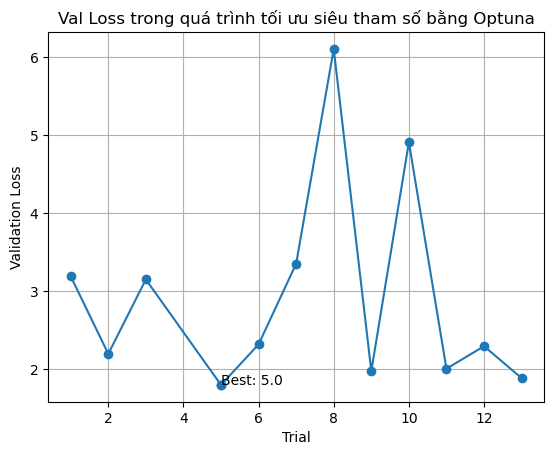

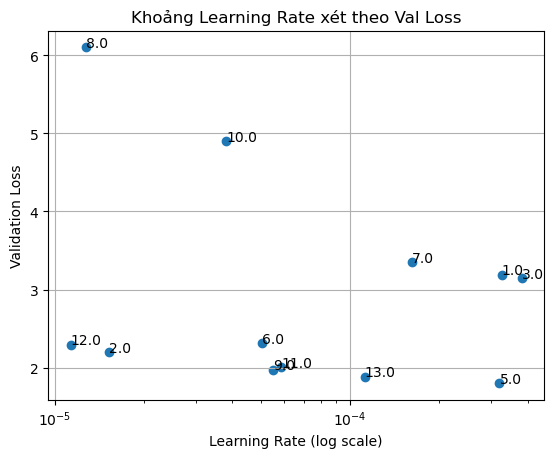

<Figure size 640x480 with 0 Axes>

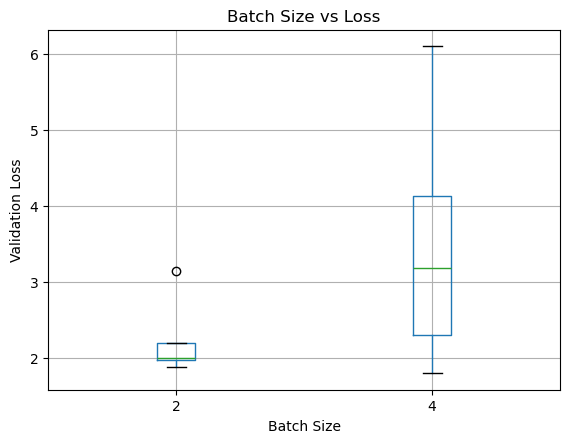

KeyError: 'num_epochs'

<Figure size 640x480 with 0 Axes>

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

trials = [
    {"trial": 1, "val_loss": 3.1903, "max_target_len": 256, "learning_rate": 3.2625788066272026e-04, "batch_size": 4, "grad_acc": 4, "num_train_epochs": 4, "weight_decay": 0.014531885775535847, "warmup_ratio": 0.0727281604591299},

    {"trial": 2, "val_loss": 2.1967, "max_target_len": 256, "learning_rate": 1.5334046838683434e-05, "batch_size": 2, "grad_acc": 4, "num_train_epochs": 6, "weight_decay": 0.0560813858913376, "warmup_ratio": 0.08832219738055468},

    {"trial": 3, "val_loss": 3.1495, "max_target_len": 256, "learning_rate": 3.8146052304894424e-04, "batch_size": 2, "grad_acc": 8, "num_train_epochs": 4, "weight_decay": 0.07087530224308672, "warmup_ratio": 0.07495133544380105},

    # Trial 4 bị loại (inf)

    {"trial": 5, "val_loss": 1.7989, "max_target_len": 320, "learning_rate": 3.210376689202368e-04, "batch_size": 4, "grad_acc": 4, "num_train_epochs": 6, "weight_decay": 0.05733349649962336, "warmup_ratio": 0.055629733095640885},

    {"trial": 6, "val_loss": 2.3178, "max_target_len": 192, "learning_rate": 5.030140763560382e-05, "batch_size": 4, "grad_acc": 4, "num_train_epochs": 6, "weight_decay": 0.023995540077321943, "warmup_ratio": 0.054333340975128847},

    {"trial": 7, "val_loss": 3.3509, "max_target_len": 256, "learning_rate": 1.6182079924163e-04, "batch_size": 4, "grad_acc": 4, "num_train_epochs": 4, "weight_decay": 0.04882386451981497, "warmup_ratio": 0.05369923420365605},

    {"trial": 8, "val_loss": 6.1009, "max_target_len": 320, "learning_rate": 1.2804330563405428e-05, "batch_size": 4, "grad_acc": 8, "num_train_epochs": 5, "weight_decay": 0.02587004270185931, "warmup_ratio": 0.05433722528430776},

    {"trial": 9, "val_loss": 1.9757, "max_target_len": 320, "learning_rate": 5.495954279981711e-05, "batch_size": 2, "grad_acc": 4, "num_train_epochs": 4, "weight_decay": 0.020819494210344344, "warmup_ratio": 0.08542967991119044},

    {"trial": 10, "val_loss": 4.9054, "max_target_len": 320, "learning_rate": 3.8182659164958085e-05, "batch_size": 4, "grad_acc": 4, "num_train_epochs": 3, "weight_decay": 0.08860750287512055, "warmup_ratio": 0.09688809799942456},

    {"trial": 11, "val_loss": 2.0058, "max_target_len": 320, "learning_rate": 5.863884178102098e-05, "batch_size": 2, "grad_acc": 8, "num_train_epochs": 6, "weight_decay": 0.03912834758041714, "warmup_ratio": 0.05937149832874079},

    {"trial": 12, "val_loss": 2.2951, "max_target_len": 320, "learning_rate": 1.1332071014274431e-05, "batch_size": 4, "grad_acc": 4, "num_train_epochs": 6, "weight_decay": 0.07772823126756934, "warmup_ratio": 0.07891164332130869},

    {"trial": 13, "val_loss": 1.8859, "max_target_len": 192, "learning_rate": 1.122652003057577e-04, "batch_size": 2, "grad_acc": 4, "num_train_epochs": 6, "weight_decay": 0.07950040243126788, "warmup_ratio": 0.058785426012074316}
]

def visualize_trials(trials):
    df = pd.DataFrame(trials)

    # ====== SORT ======
    df = df.sort_values("trial")

    # ====== BEST TRIAL ======
    best = df.loc[df["val_loss"].idxmin()]
    print("Best trial:")
    print(best)
    print("-" * 50)

    # ====== 1. VAL LOSS PER TRIAL ======
    plt.figure()
    plt.plot(df["trial"], df["val_loss"], marker='o')
    
    # highlight best
    plt.scatter(best["trial"], best["val_loss"])
    plt.text(best["trial"], best["val_loss"], f"Best: {best['trial']}")
    
    plt.xlabel("Trial")
    plt.ylabel("Validation Loss")
    plt.title("Val Loss trong quá trình tối ưu siêu tham số bằng Optuna")
    plt.grid()
    plt.show()

    # ====== 2. LEARNING RATE VS LOSS ======
    plt.figure()
    plt.scatter(df["learning_rate"], df["val_loss"])
    plt.xscale("log")
    
    for i, row in df.iterrows():
        plt.text(row["learning_rate"], row["val_loss"], str(row["trial"]))
    
    plt.xlabel("Learning Rate (log scale)")
    plt.ylabel("Validation Loss")
    plt.title("Khoảng Learning Rate xét theo Val Loss")
    plt.grid()
    plt.show()

    # ====== 3. BATCH SIZE VS LOSS ======
    plt.figure()
    df.boxplot(column="val_loss", by="batch_size")
    plt.title("Batch Size vs Loss")
    plt.suptitle("")
    plt.xlabel("Batch Size")
    plt.ylabel("Validation Loss")
    plt.show()

    # ====== 4. NUM EPOCHS VS LOSS ======
    plt.figure()
    df.boxplot(column="val_loss", by="num_epochs")
    plt.title("Num Epochs vs Loss")
    plt.suptitle("")
    plt.xlabel("Num Epochs")
    plt.ylabel("Validation Loss")
    plt.show()

    # ====== 5. MAX LEN VS LOSS ======
    plt.figure()
    df.boxplot(column="val_loss", by="max_len")
    plt.title("Max Length vs Loss")
    plt.suptitle("")
    plt.xlabel("Max Length")
    plt.ylabel("Validation Loss")
    plt.show()
    
visualize_trials(trials)